In [2]:
import pandas as pd 
import numpy as np

df = pd.read_csv("../data/crop_yield.csv")
df.head()




,State_Name,District_Name,Crop_Year,Season,Crop,Temperature,Humidity,Soil_Moisture,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,36,35,45,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,37,40,46,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,36,41,50,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,37,42,55,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,36,40,54,720.0,165.0


In [3]:
df

,State_Name,District_Name,Crop_Year,Season,Crop,Temperature,Humidity,Soil_Moisture,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,36,35,45,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,37,40,46,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,36,41,50,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,37,42,55,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,36,40,54,720.0,165.0
...,...,...,...,...,...,...,...,...,...,...
49994,Chhattisgarh,JANJGIR-CHAMPA,2006,Kharif,Small millets,36,35,45,27.0,7.0
49995,Chhattisgarh,JANJGIR-CHAMPA,2006,Kharif,Soyabean,37,40,46,27.0,32.0
49996,Chhattisgarh,JANJGIR-CHAMPA,2006,Kharif,Sunflower,36,41,50,450.0,213.0
49997,Chhattisgarh,JANJGIR-CHAMPA,2006,Kharif,Urad,37,42,55,1778.0,309.0


In [4]:
df.shape

(49999, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   State_Name     49999 non-null  object 
 1   District_Name  49999 non-null  object 
 2   Crop_Year      49999 non-null  int64  
 3   Season         49999 non-null  object 
 4   Crop           49999 non-null  object 
 5   Temperature    49999 non-null  int64  
 6   Humidity       49999 non-null  int64  
 7   Soil_Moisture  49999 non-null  int64  
 8   Area           49999 non-null  float64
 9   Production     49784 non-null  float64
dtypes: float64(2), int64(4), object(4)
memory usage: 3.8+ MB


In [6]:
df.isnull().sum()

State_Name         0
District_Name      0
Crop_Year          0
Season             0
Crop               0
Temperature        0
Humidity           0
Soil_Moisture      0
Area               0
Production       215
dtype: int64

In [7]:
set(df["Season"])

{'Autumn     ',
 'Kharif     ',
 'Rabi       ',
 'Summer     ',
 'Whole Year ',
 'Winter     '}

In [8]:
set(df["State_Name"])

{'Andaman and Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh'}

In [9]:
#Chandigarh is not a state he is a capital  of panjab so replace Chandigarh -> panjab 
df["State_Name"] = df["State_Name"].replace({"Chandigarh":"Punjab"})

In [10]:
print("Chandigarh" in df.values)  # Should return False

False


In [11]:
print("Punjab" in df.values)  # Should return True

True


In [12]:
set(df["State_Name"])

{'Andaman and Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chhattisgarh',
 'Punjab'}

In [13]:
df.groupby("State_Name")["District_Name"].nunique()

State_Name
Andaman and Nicobar Islands     3
Andhra Pradesh                 13
Arunachal Pradesh              18
Assam                          27
Bihar                          38
Chhattisgarh                   12
Punjab                          1
Name: District_Name, dtype: int64

In [14]:
df.loc[df["State_Name"]=="Bihar",["State_Name","District_Name"]].drop_duplicates()

,State_Name,District_Name
27005,Bihar,ARARIA
27571,Bihar,ARWAL
27868,Bihar,AURANGABAD
28315,Bihar,BANKA
28752,Bihar,BEGUSARAI
29342,Bihar,BHAGALPUR
29953,Bihar,BHOJPUR
30450,Bihar,BUXAR
30863,Bihar,DARBHANGA
31363,Bihar,GAYA


In [15]:
df.describe()

,Crop_Year,Temperature,Humidity,Soil_Moisture,Area,Production
count,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000,4.978400e+04
mean,2005.879138,34.445489,44.776116,53.110502,7363.389469,4.132019e+05
std,5.106092,3.498524,6.662406,5.258764,27927.935789,1.232609e+07
min,1997.000000,25.000000,35.000000,45.000000,0.200000,0.000000e+00
25%,2002.000000,34.000000,40.000000,50.000000,76.000000,8.700000e+01
50%,2006.000000,36.000000,42.000000,54.000000,436.000000,6.384400e+02
75%,2010.000000,36.000000,50.000000,55.000000,2546.500000,5.615000e+03
max,2014.000000,37.000000,55.000000,62.000000,877029.000000,7.801620e+08


In [16]:
df.groupby("State_Name")["Soil_Moisture"].describe()

,count,mean,std,min,25%,50%,75%,max
State_Name,,,,,,,,
Andaman and Nicobar Islands,203.0,53.034483,5.267479,45.0,50.0,54.0,55.0,62.0
Andhra Pradesh,9628.0,53.110823,5.259514,45.0,50.0,54.0,55.0,62.0
Arunachal Pradesh,2546.0,53.112333,5.260442,45.0,50.0,54.0,55.0,62.0
Assam,14628.0,53.111362,5.258945,45.0,50.0,54.0,55.0,62.0
Bihar,18885.0,53.109717,5.258700,45.0,50.0,54.0,55.0,62.0
Chhattisgarh,4019.0,53.112963,5.258351,45.0,50.0,54.0,55.0,62.0
Punjab,90.0,53.111111,5.288199,45.0,50.0,54.0,55.0,62.0


hare we can directly see that in a soil_Moisture of a values min ,max,25%,50%,75% of the all state has as it is same data for all the state but each state has  a diff soil_moisture ,accoridng to the wather do that are giving  a incossistancy that's why we are droping a this columns 

In [17]:
df = df.drop("Soil_Moisture",axis=1)

hare yeild X area = production 
 we want total yeild  and we have 
 area and production 

 yeild = production /area

 

In [18]:
df["Yeild"] = (df["Production"]/df["Area"])

In [19]:
df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Temperature,Humidity,Area,Production,Yeild
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,36,35,1254.0,2000.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,37,40,2.0,1.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,36,41,102.0,321.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,37,42,176.0,641.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,36,40,720.0,165.0,0.229167


Area       → hectares (ha)


Production → tonnes (t)



Yield      → tonnes/hectare (t/ha)




In [20]:
df = df.drop(columns=["Crop_Year","Area","Production"])
df.head()

,State_Name,District_Name,Season,Crop,Temperature,Humidity,Yeild
0,Andaman and Nicobar Islands,NICOBARS,Kharif,Arecanut,36,35,1.594896
1,Andaman and Nicobar Islands,NICOBARS,Kharif,Other Kharif pulses,37,40,0.500000
2,Andaman and Nicobar Islands,NICOBARS,Kharif,Rice,36,41,3.147059
3,Andaman and Nicobar Islands,NICOBARS,Whole Year,Banana,37,42,3.642045
4,Andaman and Nicobar Islands,NICOBARS,Whole Year,Cashewnut,36,40,0.229167


we drop the ["Crop_Year","Area","Production"]) becouse of the this columns are calculated by 


        production = yeild * production 
and crop year are not the our feature 

In [21]:
df.isna().sum()

State_Name         0
District_Name      0
Season             0
Crop               0
Temperature        0
Humidity           0
Yeild            215
dtype: int64

hare yeild has the 215 empty val and yeild are a our label 
so we are droping a those val hare becouse if we replace them with a mean or madian  if craate a artificial output 
so thats why we are droing a that val 
''

In [22]:
df.dropna(subset=["Yeild"],inplace= True)

In [23]:
df.isnull().sum()

State_Name       0
District_Name    0
Season           0
Crop             0
Temperature      0
Humidity         0
Yeild            0
dtype: int64

In [24]:
df.shape

(49784, 7)

In [25]:
df.head()

,State_Name,District_Name,Season,Crop,Temperature,Humidity,Yeild
0,Andaman and Nicobar Islands,NICOBARS,Kharif,Arecanut,36,35,1.594896
1,Andaman and Nicobar Islands,NICOBARS,Kharif,Other Kharif pulses,37,40,0.500000
2,Andaman and Nicobar Islands,NICOBARS,Kharif,Rice,36,41,3.147059
3,Andaman and Nicobar Islands,NICOBARS,Whole Year,Banana,37,42,3.642045
4,Andaman and Nicobar Islands,NICOBARS,Whole Year,Cashewnut,36,40,0.229167


In [26]:
# now split the model into a treinig and testing dataset 
from sklearn.model_selection import train_test_split 

#we want to suffule dataset of the crop for testing so 
# we want a variours crop for thesting so we apply a staatify on a crop column to test   a various crop on a traind model
df = df[df["Crop"].map(df["Crop"].value_counts()) > 2]

train_set, test_set = train_test_split(df,
                                      stratify=df["Crop"],
                                      test_size=0.2,
                                      random_state=42
                                      )


In [27]:
train_set.head()

,State_Name,District_Name,Season,Crop,Temperature,Humidity,Yeild
19254,Assam,HAILAKANDI,Winter,Rice,36,40,2.317987
49739,Chhattisgarh,GARIYABAND,Kharif,Small millets,36,41,0.150895
29624,Bihar,BHAGALPUR,Whole Year,Garlic,35,50,1.509434
38174,Bihar,NALANDA,Rabi,Khesari,37,40,1.769969
39517,Bihar,PATNA,Rabi,Barley,37,42,1.010309


In [28]:
test_set.shape

(9957, 7)

In [29]:
#Now work with trainset 
df_feature = train_set.drop("Yeild",axis=1)
df_label = train_set["Yeild"]

In [30]:
#now saprate the catgorical value and numrical valueabs 
df_feature_cat = df_feature.drop(columns=["Temperature","Humidity"],axis= 1).columns.to_list()
df_feature_num = df_feature.select_dtypes(include="number").columns.to_list()

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

cat_pipeline = Pipeline([
        ("encoding",OneHotEncoder())
])

num_pipeline = Pipeline([
        ("scaling",StandardScaler())
])


In [32]:
cat_pipeline

,steps,"[('encoding', ...)]"
,transform_input,None
,memory,None
,verbose,False
,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None


In [33]:
num_pipeline

,steps,"[('scaling', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True


In [34]:
from sklearn.compose import ColumnTransformer 

final_pipeline = ColumnTransformer([
        ("Cat val ",cat_pipeline,df_feature_cat),
        ("num val", num_pipeline,df_feature_num)
])
final_pipeline

,transformers,"[('Cat val ', ...), ('num val', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [35]:
prepared_df = final_pipeline.fit_transform(df_feature)

In [36]:
pd.DataFrame(prepared_df.toarray(),columns=final_pipeline.get_feature_names_out(),index=df_feature.index).head()

,Cat val __State_Name_Andaman and Nicobar Islands,Cat val __State_Name_Andhra Pradesh,Cat val __State_Name_Arunachal Pradesh,Cat val __State_Name_Assam,Cat val __State_Name_Bihar,Cat val __State_Name_Chhattisgarh,Cat val __State_Name_Punjab,Cat val __District_Name_ANANTAPUR,Cat val __District_Name_ANJAW,Cat val __District_Name_ARARIA,...,Cat val __Crop_Tobacco,Cat val __Crop_Tomato,Cat val __Crop_Turmeric,Cat val __Crop_Urad,Cat val __Crop_Varagu,Cat val __Crop_Wheat,Cat val __Crop_other misc. pulses,Cat val __Crop_other oilseeds,num val__Temperature,num val__Humidity
19254,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.443477,-0.716785
49739,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.443477,-0.566368
29624,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.156851,0.787385
38174,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.730103,-0.716785
39517,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.730103,-0.415951


In [37]:
#PIPELINE ARE DONE NOW TEST THE PROCESSED DATA WITH THE DIFFRENT MODEL
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

lin_model = LinearRegression()
lin_model.fit(prepared_df,df_label)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
predictions = lin_model.predict(prepared_df)
rsme = -cross_val_score(lin_model,prepared_df,df_label,cv=10,scoring="neg_root_mean_squared_error")
print(pd.DataFrame(rsme).describe())
mae = mean_absolute_error(df_label,predictions)
print(mae)

                0
count   10.000000
mean   545.365089
std     81.292349
min    419.687740
25%    499.352412
50%    543.216602
75%    579.459730
max    707.821982
86.30173693064512


In [39]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

dec_model = DecisionTreeRegressor()
dec_model.fit(prepared_df,df_label)

dec_pred= dec_model.predict(prepared_df)
rsme_reg = -cross_val_score(dec_model,prepared_df,df_label,cv=10,scoring="neg_root_mean_squared_error")
mae_reg = mean_absolute_error(df_label,dec_pred)
print(mae_reg)
print(pd.DataFrame(rsme_reg).describe())

19.038247367506443
                0
count   10.000000
mean   550.888240
std     53.341300
min    483.196055
25%    516.339271
50%    545.119744
75%    587.658688
max    654.099536


In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

reg_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
reg_model.fit(prepared_df,df_label)

prid_ran = reg_model.predict(prepared_df)
rsme_ran = -cross_val_score(reg_model,prepared_df,df_label,cv=5,scoring="neg_root_mean_squared_error")
print(pd.DataFrame(rsme_ran).describe())
mae_ran = mean_absolute_error(df_label,prid_ran)
print(mae_ran)

KeyboardInterrupt: 

In [41]:
from xgboost import XGBRegressor

xg_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xg_model.fit(prepared_df,df_label)

prid_xg = xg_model.predict(prepared_df)
rsme_xg = -cross_val_score(xg_model,prepared_df,df_label,cv=5,scoring="neg_root_mean_squared_error")
print(pd.DataFrame(rsme_xg).describe())
mae_xg = mean_absolute_error(df_label,prid_xg)
print(mae_xg)

                0
count    5.000000
mean   500.406671
std     29.627035
min    466.676144
25%    479.674707
50%    498.183986
75%    515.866377
max    541.632139
31.09952231470513


In [42]:
print("Target:")
print(df_label.describe())

print("\nTarget min:", df_label.min())
print("Target max:", df_label.max())

Target:
count    39824.000000
mean        83.754022
std        914.932864
min          0.000000
25%          0.615385
50%          1.050580
75%          2.870181
max      28334.155972
Name: Yeild, dtype: float64

Target min: 0.0
Target max: 28334.155972359327


In [43]:
print(
    train_set.sort_values("Yeild", ascending=False)[
        ["State_Name", "District_Name", "Season", "Crop", "Temperature", "Humidity", "Yeild"]
    ].head(20)
)

           State_Name   District_Name       Season      Crop  Temperature  \
20171           Assam          KAMRUP  Whole Year   Coconut            37   
22705           Assam       LAKHIMPUR  Whole Year   Coconut            25   
18503           Assam        GOLAGHAT  Whole Year   Coconut            36   
18565           Assam        GOLAGHAT  Whole Year   Coconut            25   
18598           Assam        GOLAGHAT  Whole Year   Coconut            34   
8509   Andhra Pradesh  VISAKHAPATANAM  Whole Year   Coconut            36   
3230   Andhra Pradesh          GUNTUR  Whole Year   Coconut            25   
6326   Andhra Pradesh        PRAKASAM  Whole Year   Coconut            25   
7603   Andhra Pradesh      SRIKAKULAM  Whole Year   Coconut            35   
18632           Assam        GOLAGHAT  Whole Year   Coconut            37   
9790   Andhra Pradesh   WEST GODAVARI  Whole Year   Coconut            35   
4601   Andhra Pradesh         KRISHNA  Whole Year   Coconut            36   

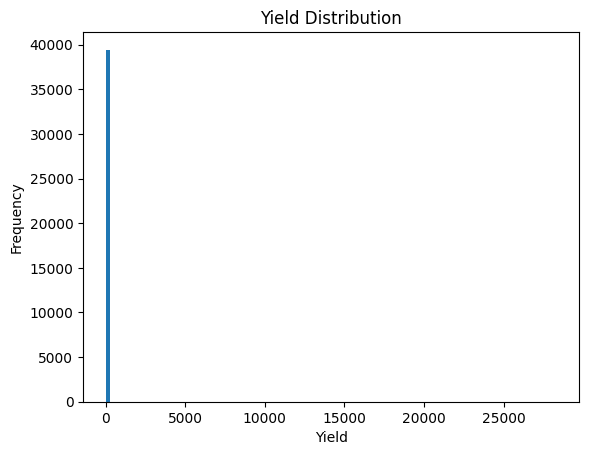

In [44]:
import matplotlib.pyplot as plt

plt.hist(df_label, bins=100)
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.title("Yield Distribution")
plt.show()

In [56]:
raw_df = pd.read_csv("../data/crop_yield.csv")
raw_df["Crop"] = (
    
    raw_df["Crop"]
    .astype(str)
    .str.strip()
)

In [57]:
print(raw_df["Crop"].unique())

['Arecanut' 'Other Kharif pulses' 'Rice' 'Banana' 'Cashewnut' 'Coconut'
 'Dry ginger' 'Sugarcane' 'Sweet potato' 'Tapioca' 'Black pepper'
 'Dry chillies' 'other oilseeds' 'Turmeric' 'Maize' 'Moong(Green Gram)'
 'Urad' 'Arhar/Tur' 'Groundnut' 'Sunflower' 'Bajra' 'Castor seed'
 'Cotton(lint)' 'Horse-gram' 'Jowar' 'Korra' 'Ragi' 'Tobacco' 'Gram'
 'Wheat' 'Masoor' 'Sesamum' 'Linseed' 'Safflower' 'Onion'
 'other misc. pulses' 'Samai' 'Small millets' 'Coriander' 'Potato'
 'Other  Rabi pulses' 'Soyabean' 'Beans & Mutter(Vegetable)' 'Bhindi'
 'Brinjal' 'Citrus Fruit' 'Cucumber' 'Grapes' 'Mango' 'Orange'
 'other fibres' 'Other Fresh Fruits' 'Other Vegetables' 'Papaya'
 'Pome Fruit' 'Tomato' 'Rapeseed &Mustard' 'Mesta' 'Cowpea(Lobia)' 'Lemon'
 'Pome Granet' 'Sapota' 'Cabbage' 'Peas  (vegetable)' 'Niger seed'
 'Bottle Gourd' 'Sannhamp' 'Varagu' 'Garlic' 'Ginger' 'Oilseeds total'
 'Pulses total' 'Jute' 'Peas & beans (Pulses)' 'Blackgram' 'Paddy'
 'Pineapple' 'Barley' 'Khesari' 'Guar seed']


In [58]:
coconut_check = raw_df[
    raw_df["Crop"] == "Coconut"
].copy()

coconut_check["Yeild"] = (
    coconut_check["Production"] / coconut_check["Area"]
)

print(
    coconut_check.sort_values(
        "Yeild",
        ascending=False
    )[
        ["State_Name", "District_Name", "Season",
         "Crop", "Area", "Production", "Yeild"]
    ].head(20)
)

           State_Name   District_Name       Season     Crop     Area  \
9829   Andhra Pradesh   WEST GODAVARI  Whole Year   Coconut  21729.0   
20171           Assam          KAMRUP  Whole Year   Coconut   2026.0   
22705           Assam       LAKHIMPUR  Whole Year   Coconut    192.0   
18503           Assam        GOLAGHAT  Whole Year   Coconut    658.0   
7697   Andhra Pradesh      SRIKAKULAM  Whole Year   Coconut  13811.0   
18565           Assam        GOLAGHAT  Whole Year   Coconut    612.0   
18598           Assam        GOLAGHAT  Whole Year   Coconut    639.0   
7008   Andhra Pradesh    SPSR NELLORE  Whole Year   Coconut    491.0   
4690   Andhra Pradesh         KRISHNA  Whole Year   Coconut   1829.0   
8509   Andhra Pradesh  VISAKHAPATANAM  Whole Year   Coconut   7416.0   
3230   Andhra Pradesh          GUNTUR  Whole Year   Coconut    112.0   
6326   Andhra Pradesh        PRAKASAM  Whole Year   Coconut     37.0   
7603   Andhra Pradesh      SRIKAKULAM  Whole Year   Coconut  144

In [61]:
df = df[df["Yeild"] < 100]

In [62]:
df

,State_Name,District_Name,Season,Crop,Temperature,Humidity,Yeild
0,Andaman and Nicobar Islands,NICOBARS,Kharif,Arecanut,36,35,1.594896
1,Andaman and Nicobar Islands,NICOBARS,Kharif,Other Kharif pulses,37,40,0.500000
2,Andaman and Nicobar Islands,NICOBARS,Kharif,Rice,36,41,3.147059
3,Andaman and Nicobar Islands,NICOBARS,Whole Year,Banana,37,42,3.642045
4,Andaman and Nicobar Islands,NICOBARS,Whole Year,Cashewnut,36,40,0.229167
...,...,...,...,...,...,...,...
49994,Chhattisgarh,JANJGIR-CHAMPA,Kharif,Small millets,36,35,0.259259
49995,Chhattisgarh,JANJGIR-CHAMPA,Kharif,Soyabean,37,40,1.185185
49996,Chhattisgarh,JANJGIR-CHAMPA,Kharif,Sunflower,36,41,0.473333
49997,Chhattisgarh,JANJGIR-CHAMPA,Kharif,Urad,37,42,0.173791


In [64]:
raw_df["Yeild"] = raw_df["Production"] / raw_df["Area"]

crop_stats = raw_df.groupby("Crop")["Yeild"].agg(
    ["count", "mean", "median", "min", "max"]
).sort_values("median", ascending=False)

print(crop_stats)

                   count         mean       median        min           max
Crop                                                                       
Coconut              587  6802.246454  6891.930836   0.494624  33089.005477
Sugarcane           1514    42.235898    39.000000   0.644619    500.491525
Papaya               228    41.986933    21.300231   0.162437    134.142636
Grapes                17    20.593308    18.200000  17.250000     31.957983
Pineapple            154    15.691724    15.382053   8.080734     19.766038
...                  ...          ...          ...        ...           ...
Bottle Gourd          21     0.000000     0.000000   0.000000      0.000000
Cucumber              24     0.000000     0.000000   0.000000      0.000000
Peas  (vegetable)      3     0.000000     0.000000   0.000000      0.000000
other fibres           2     0.000000     0.000000   0.000000      0.000000
Other Vegetables      26     0.000000     0.000000   0.000000      0.000000

[80 rows x 